# step 1: importing libraries

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# step2 :load the dataset 

In [11]:
df = pd.read_csv("../data/creditcard.csv")

In [16]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# step3 : understand the dataset 

In [17]:
df.shape

(284807, 31)

In [18]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [20]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# step4 : check missing values 

In [21]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# step 5: check duplicate records 

In [22]:
df.duplicated().sum()

np.int64(1081)

In [23]:
df = df.drop_duplicates()

In [24]:
df.duplicated().sum()

np.int64(0)

# step6: understand feaud vs legitimate transactions 

In [25]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

# step 7: visualize fraud distribution 

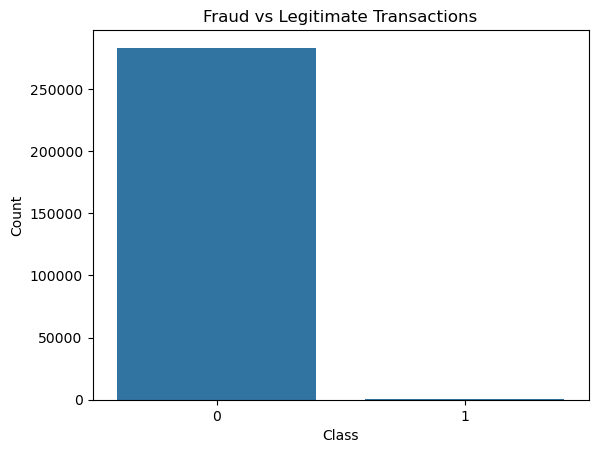

In [26]:
sns.countplot(x='Class', data=df)

plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()

# step 8: calculate feaud percentage 

In [27]:
fraud_percentage = df['Class'].value_counts(normalize=True) * 100

print(fraud_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [28]:
fraud_count = df['Class'].sum()
total_count = len(df)

fraud_percentage = (fraud_count / total_count) * 100

print("Fraud Percentage:", fraud_percentage)

Fraud Percentage: 0.1667101358352777


# step 9 : analyze transaction amount 

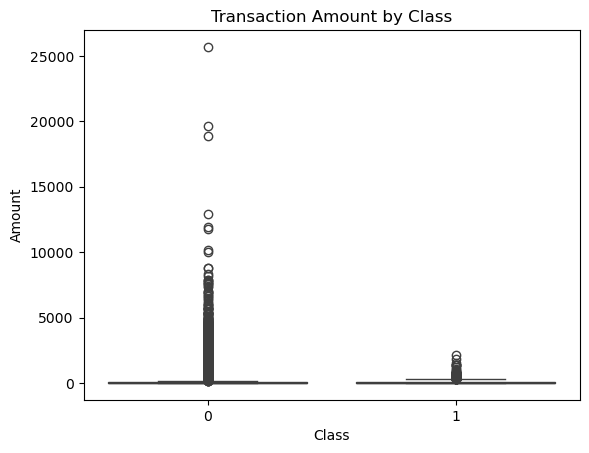

In [29]:
sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount by Class')
plt.show()

# step 10: Analyze time

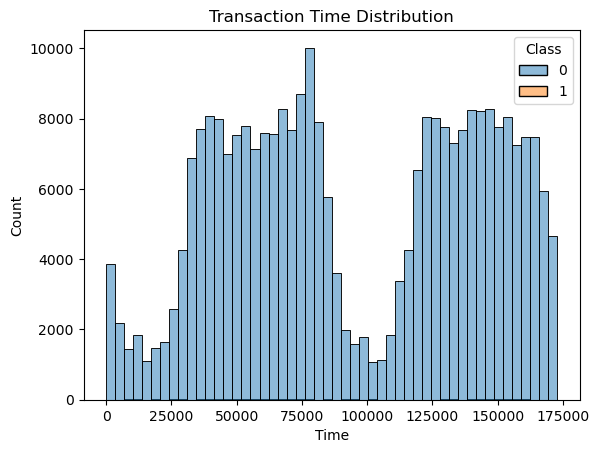

In [30]:
sns.histplot(data=df, x='Time', hue='Class', bins=50)

plt.title('Transaction Time Distribution')
plt.show()

# step 11: check correlation 

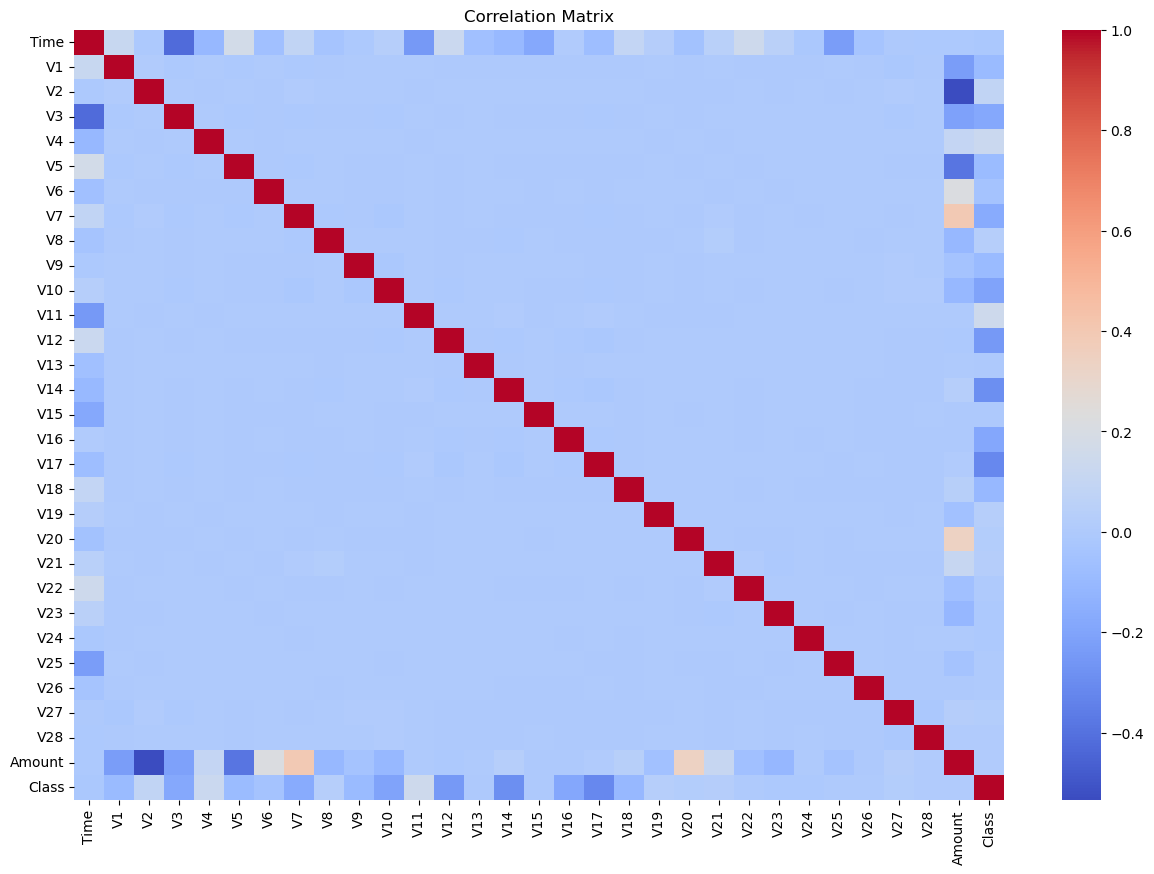

In [31]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# step12: separate x and y 

In [32]:
X = df.drop('Class', axis=1)
y = df['Class']

X = input features
y = target/output

# step 13: split the data 

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#  step14: feature scaling 

In [34]:

scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(
    X_train[['Time', 'Amount']]
)

X_test[['Time', 'Amount']] = scaler.transform(
    X_test[['Time', 'Amount']]
)

# step 15: build logistic regression 

In [35]:
model_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model_lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [36]:
y_pred_lr = model_lr.predict(X_test)

# step 16: evalute logistic regression 

In [37]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

Accuracy: 0.9752405455891164
Precision: 0.05623306233062331
Recall: 0.8736842105263158
F1 Score: 0.10566518141311267


# step 17 : confusion matrix 

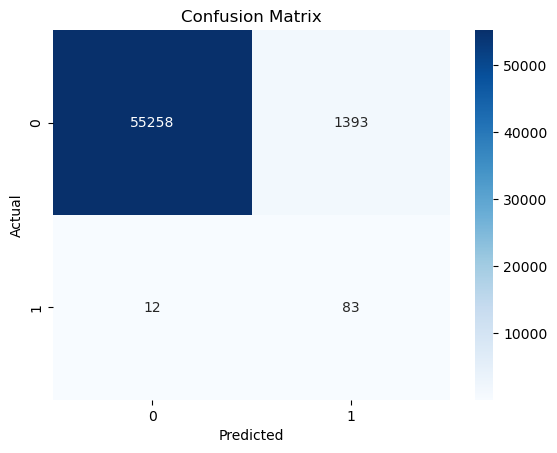

In [38]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

# step 18 : build random forest 

In [43]:
y_pred_rf = rf.predict(X_test)

NameError: name 'rf' is not defined

# step 19: evaluate random forest 

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

In [ ]:
print(classification_report(y_test, y_pred_rf))

# step 20: calculate ROC-AUC

In [40]:
y_probability = rf.predict_proba(X_test)[:, 1]

NameError: name 'rf' is not defined

In [41]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", roc_auc)

NameError: name 'y_probability' is not defined

# step 21: calculate PR-AUC

In [42]:
pr_auc = average_precision_score(
    y_test,
    y_probability
)

print("PR-AUC:", pr_auc)

NameError: name 'y_probability' is not defined

# step 22: compare models 

In [36]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.975241,0.056233,0.873684,0.105665
1,Random Forest,0.999489,0.971429,0.715789,0.824242


# step 23: add smote 

In [44]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [31]:
from imblearn.over_sampling import SMOTE

In [32]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

In [33]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


# step24: train random forest with smote 

In [2]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

NameError: name 'RandomForestClassifier' is not defined

In [1]:
y_pred_smote = rf_smote.predict(X_test)  

NameError: name 'rf_smote' is not defined

In [2]:
print(classification_report(
    y_test,
    y_pred_smote
))

NameError: name 'classification_report' is not defined

# step25: use grid search cv 

In [3]:
from sklearn.model_selection import GridSearchCV

In [4]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [5]:
grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

NameError: name 'RandomForestClassifier' is not defined

In [6]:
grid_search.fit(
    X_train,
    y_train
)

NameError: name 'grid_search' is not defined

# step26: find best parameters 

In [7]:
print(grid_search.best_params_)

NameError: name 'grid_search' is not defined

# step 27: get the best model 

In [8]:
best_model = grid_search.best_estimator_

NameError: name 'grid_search' is not defined

In [9]:
y_pred_best = best_model.predict(X_test)

NameError: name 'best_model' is not defined

# step28: final evaluation 

In [10]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("Precision:",
      precision_score(y_test, y_pred_best))

print("Recall:",
      recall_score(y_test, y_pred_best))

print("F1 Score:",
      f1_score(y_test, y_pred_best))

print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred_best
))

NameError: name 'accuracy_score' is not defined

# step 29: confusion matrix for final model 

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Fraud Detection Confusion Matrix')

plt.show()

NameError: name 'confusion_matrix' is not defined

# step30: feature importance 

In [12]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(15))

NameError: name 'pd' is not defined

In [13]:
plt.figure(figsize=(10,6))

importance.head(15).plot(kind='bar')

plt.title('Top 15 Important Features')

plt.xlabel('Features')
plt.ylabel('Importance')

plt.show()

NameError: name 'plt' is not defined

# step 31: save the model 

In [14]:
import joblib

In [15]:
joblib.dump(
    best_model,
    '../models/fraud_model.pkl'
)

NameError: name 'best_model' is not defined

In [16]:
joblib.dump(
    scaler,
    '../models/scaler.pkl'
)

NameError: name 'scaler' is not defined

# step 32: create streamlit application 

In [17]:
app.py

NameError: name 'app' is not defined

In [18]:
import streamlit as st
import pandas as pd
import joblib

In [19]:
model = joblib.load(
    'models/fraud_model.pkl'
)

scaler = joblib.load(
    'models/scaler.pkl'
)

FileNotFoundError: [Errno 2] No such file or directory: 'models/fraud_model.pkl'

In [20]:
st.title("🛡️ Credit Card Fraud Detection System")

st.write(
    "Enter transaction information to predict whether "
    "the transaction is potentially fraudulent."
)

2026-08-12 21:57:11.432 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:57:11.674 
  command:

    streamlit run C:\Users\User\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-12 21:57:11.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:57:11.679 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:57:11.680 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


# step 33: create input fields 

In [21]:
time = st.number_input(
    "Transaction Time",
    value=0.0
)

amount = st.number_input(
    "Transaction Amount",
    value=0.0
)

2026-08-12 21:58:29.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:58:29.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:58:29.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:58:29.968 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:58:29.969 Session state does not function when running a script without `streamlit run`
2026-08-12 21:58:29.970 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:58:29.971 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:58:29.972 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 21:58

v_features = {}

for i in range(1, 29):

    v_features[f'V{i}'] = st.number_input(
        f'V{i}',
        value=0.0
    )

In [23]:
data = {
    'Time': time,
    'Amount': amount
}

data.update(v_features)

input_data = pd.DataFrame(
    [data]
)

# step34: scale input data 

In [24]:
input_data[['Time', 'Amount']] = scaler.transform(
    input_data[['Time', 'Amount']]
)


NameError: name 'scaler' is not defined

# step35:predict fraud 

if st.button("Check Transaction"):

    probability = model.predict_proba(
        input_data
    )[0][1]

    prediction = model.predict(
        input_data
    )[0]

In [26]:
if st.button("Check Transaction"):

    probability = model.predict_proba(
        input_data
    )[0][1]

    prediction = model.predict(
        input_data
    )[0]

2026-08-12 22:01:08.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:01:08.521 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:01:08.526 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:01:08.530 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:01:08.569 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


# step36: run the application 

In [27]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

# step 37 : improve the streamlit UI 

In [28]:
col1, col2, col3 = st.columns(3)

col1.metric(
    "Fraud Probability",
    f"{probability:.2%}"
)

col2.metric(
    "Prediction",
    "Fraud" if prediction == 1 else "Legitimate"
)

col3.metric(
    "Threshold",
    "50%"
)

2026-08-12 22:03:50.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:03:50.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:03:50.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:03:50.234 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


NameError: name 'probability' is not defined

# step 38: add batch prediction 

In [29]:
uploaded_file = st.file_uploader(
    "Upload transaction CSV",
    type=['csv']
)

2026-08-12 22:05:14.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:05:14.139 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:05:14.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:05:14.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-12 22:05:14.167 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [30]:
if uploaded_file:

    uploaded_data = pd.read_csv(
        uploaded_file
    )

    st.dataframe(
        uploaded_data.head()
    )

In [31]:
predictions = model.predict(
    uploaded_data
)

NameError: name 'model' is not defined

In [32]:
uploaded_data['Prediction'] = predictions

NameError: name 'predictions' is not defined

In [33]:
st.dataframe(
    uploaded_data
)

NameError: name 'uploaded_data' is not defined